In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from skimage.measure import find_contours

from unc_handling import UG_prompter
from DataLoader import DataLoader
from segmentation import Segmentation
from segmentation_util import combine_prompt_sets
from evaluation import Evaluator, compare_to_recontours

root = r"C:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\data\LUNDPROBE\ExtendedSamples\development"
selected_slice = 43
sub_nr = 4

In [2]:
def run_prompt_strategy(data, prompt_dict, name, selected_slice = None ,propagation_style="central_start"):
    """
    Runs one prompt strategy in a fresh Segmentation object.
    This avoids prompt/memory contamination between strategies.
    """
    seg_handler = Segmentation(data=data)

    seg_handler.compile_prompt_sets(
        prompt_dict_list=[prompt_dict],
        prompt_set_names=[name],
        prompt_set_weights=[1.0],
    )

    if selected_slice is not None:
        seg_handler.reduce_to_slice(selected_slice)

    seg_handler.run_segmentation_sets(
        propagation_style=propagation_style,
        weighting_strategy="average",
        threshold=0.0,
    )

    seg_handler.remove_distant_slices(tolerance_frames=0)

    return np.asarray(seg_handler.predicted_seg).astype(bool), np.asarray(seg_handler.predicted_logits)

def run_prompt_strategy_sets(data, prompt_dicts, weightlist, namelist, selected_slice=None, propagation_style="central_start"):
    """
    Runs one prompt strategy in a fresh Segmentation object.
    This avoids prompt/memory contamination between strategies.
    """
    seg_handler = Segmentation(data=data)

    seg_handler.compile_prompt_sets(
        prompt_dict_list=prompt_dicts,
        prompt_set_names=namelist,
        prompt_set_weights=weightlist,
    )

    if selected_slice is not None:
        seg_handler.reduce_to_slice(selected_slice)

    seg_handler.run_segmentation_sets(
        propagation_style=propagation_style,
        weighting_strategy="custom",
        threshold=0.0,

    )

    seg_handler.remove_distant_slices(tolerance_frames=0)

    return np.asarray(seg_handler.predicted_seg).astype(bool), np.asarray(seg_handler.predicted_logits)



In [3]:
def remove_negative_prompts(prompt_dict):
    filtered = {}

    for z, prompts in prompt_dict.items():

        points = prompts.get("points")
        labels = prompts.get("point_labels")

        if points is None or labels is None:
            filtered[z] = prompts
            continue

        keep = labels == 1

        filtered[z] = {
            **prompts,
            "points": points[keep],
            "point_labels": labels[keep],
        }

    return filtered

def remove_positive_prompts(prompt_dict):
    filtered = {}

    for z, prompts in prompt_dict.items():

        points = prompts.get("points")
        labels = prompts.get("point_labels")

        if points is None or labels is None:
            filtered[z] = prompts
            continue

        keep = labels == 0

        filtered[z] = {
            **prompts,
            "points": points[keep],
            "point_labels": labels[keep],
        }

    return filtered

In [4]:
data = DataLoader(parentfolder=root,subject_nr=sub_nr,volume_of_interest="CTVT",verbose=True,)
data.load_recontours()
unc_handler = UG_prompter(data=data)
method = "local_normals"
unc_handler.threshold_uncertainty_map(unc_threshold=None,target_mm=3.0,method="raycast",mode="median",)
unc_handler.compute_band_thickness(method=method)

tmp_seg = Segmentation(data=data)
dense_prompt = tmp_seg.load_dense_prompt()

# 16 increasingly sparse nietjes prompt strategies
pixel_intervals = [1, 2, 3, 4, 5, 7, 10, 12, 15, 20, 25, 30, 40, 50, 75, 100]
pixel_intervals_small = [10,15]
grid_sizes = [2,4,5,6,8,10,15,20,25,30,35,40,50,75,100]
padding_vals = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]

prompt_strategies = {}
prompt_sets = {}

# for pixel_interval in pixel_intervals:

#     nietjes_indiscriminate = unc_handler.generate_prompts_nietjes(
#         unc_band_thr_mm=0.0,
#         interpix_dist=5,
#         pixel_interval=pixel_interval,
#         angle_step=5,
#         method=method,
#     )

#     nietjes_uncertainty_guided = unc_handler.generate_prompts_nietjes(
#         unc_band_thr_mm=3.0,
#         interpix_dist=3,
#         pixel_interval=pixel_interval,
#         angle_step=5,
#         method=method,
#     )

#     prompt_strategies[f"Nietjes\ninterval={pixel_interval}"] = combine_prompt_sets([nietjes_uncertainty_guided,dense_prompt])


for padding_val in padding_vals:
    
    bbox_uncertainty_guided = unc_handler.generate_prompts_boxes(
        band_threshold=0.0,
        pad=padding_val,
    )

    prompt_strategies[f"BBox\npadding={padding_val}"] = combine_prompt_sets([bbox_uncertainty_guided,dense_prompt])




Loaded subject newAcq_1e0f8b9b01ce5f0b with volume of interest 'CTVT'
Image shape: (88, 1024, 1024), Mask shape: (88, 1024, 1024), Uncertainty map shape: (88, 1024, 1024), Ground truth shape: (88, 1024, 1024)
Image spacing (z, y, x): (2.5, 0.46880000829696655, 0.46880000829696655)
Initilialized UG_prompter for subject 4 with volume of interest 'CTVT'
Image shape: (88, 1024, 1024), Mask shape: (88, 1024, 1024), Uncertainty map shape: (88, 1024, 1024).
iter=00 | thr=0.201742 | band=0.59 mm | error=2.41
iter=01 | thr=0.100871 | band=1.05 mm | error=1.95
iter=02 | thr=0.050435 | band=1.52 mm | error=1.48
iter=03 | thr=0.025218 | band=1.99 mm | error=1.01
iter=04 | thr=0.012609 | band=2.58 mm | error=0.42
iter=05 | thr=0.006304 | band=3.05 mm | error=0.05
iter=06 | thr=0.009457 | band=2.81 mm | error=0.19
iter=07 | thr=0.007881 | band=2.93 mm | error=0.07
iter=08 | thr=0.007092 | band=2.93 mm | error=0.07
iter=09 | thr=0.006698 | band=3.05 mm | error=0.05
iter=10 | thr=0.006895 | band=3.05 

c:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\sam2\modeling\sam\transformer.py:23: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


In [5]:
seg_results = {}
log_results = {}

for name, prompt_dict in prompt_strategies.items():

    print(f"Running: {name}")

    seg_results[name], log_results[name] = run_prompt_strategy(
        data=data,
        prompt_dict=prompt_dict,
        name=name,
        selected_slice=selected_slice,
        propagation_style="central_start",
    )


for strategy_name, config in prompt_sets.items():

    print(f"Running: {strategy_name}")

    pred_seg, pred_logits = run_prompt_strategy_sets(
        data=data,
        prompt_dicts=config["prompt_dicts"],
        weightlist=config["weights"],
        namelist=config["names"],
        propagation_style="central_start",
        selected_slice=selected_slice
    )

    seg_results[strategy_name] = pred_seg
    log_results[strategy_name] = pred_logits


plot_prompt_strategies = {}
plot_prompt_strategies.update(prompt_strategies)
plot_prompt_strategies.update(prompt_sets)

Running: BBox
padding=0
Initialized Segmentation for subject 4 with volume of interest 'CTVT'
Mask shape: (88, 1024, 1024)
Building SAM predictor from checkpoint: checkpoints/MedSAM2_latest.pt
Running segmentation for prompt set 'BBox
padding=0' with slices: [0]
Device: cuda
Volume shape (D,H,W): (1, 1024, 1024)
Using prompts from slices: [0]
Adding prompt(s) on slice 0


c:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\sam2\sam2_video_predictor_npz.py:965: UserWarning: cannot import name '_C' from 'sam2' (c:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\sam2\__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


Forward propagation (central_start, from slice 0)...


propagate in video: 100%|██████████| 1/1 [00:00<00:00, 181.45it/s]


Backward propagation (central_start, from slice 0)...


...

Running segmentation for prompt set 'BBox
padding=15' with slices: [0]
Device: cuda
Volume shape (D,H,W): (1, 1024, 1024)
Using prompts from slices: [0]
Adding prompt(s) on slice 0
Forward propagation (central_start, from slice 0)...


propagate in video: 100%|██████████| 1/1 [00:00<00:00, 86.52it/s]


Backward propagation (central_start, from slice 0)...


propagate in video: 0it [00:00, ?it/s]

Kept slices 0 to 0. Removed predicted segmentation outside dense mask ±0 slices.


In [6]:
print(prompt_dict[selected_slice])

{'points': None, 'point_labels': None, 'bbox': array([442., 503., 582., 625.], dtype=float32), 'mask_input': array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1024, 1024), dtype=uint8)}


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from skimage.measure import find_contours


def interactive_single_slice_prompt_strategy_comparison(
    data,
    seg_results,
    prompt_strategies,
    selected_slice,
    zoom_fraction=0.20,
    figsize_per_plot=4,
    savefig=True,
    show_uncertainty=False,
    show_gt=False,
    plot_recontour=False,
    recontour_index=0,
    savepath=None,
):
    img = np.asarray(data.img)
    gt = np.asarray(data.gt).astype(bool)
    dense = np.asarray(data.mask).astype(bool)

    image_z = selected_slice
    pred_z = 0
    prompt_z = selected_slice

    if savepath is None:
        savepath = f"segmentation_comparison_slice_{selected_slice}.png"

    if show_uncertainty:
        unc_bin = np.asarray(unc_handler.unc_map_bin).astype(bool)
    else:
        unc_bin = None

    if plot_recontour:
        recontour = np.asarray(data.observer_recontours[recontour_index]).astype(bool)
    else:
        recontour = None

    def draw_contour(ax, mask, color, linewidth=1.0, linestyle="-"):
        if mask is None or not np.any(mask):
            return

        contours = find_contours(mask.astype(float), 0.5)

        for contour in contours:
            ax.plot(
                contour[:, 1],
                contour[:, 0],
                color=color,
                linewidth=linewidth,
                linestyle=linestyle,
            )

    def draw_prompts(ax, prompt_dict, z, x0, y0):
        if z not in prompt_dict:
            return

        prompts = prompt_dict[z]

        points = prompts.get("points", None)
        labels = prompts.get("point_labels", None)

        if points is not None and labels is not None:
            points = np.asarray(points)
            labels = np.asarray(labels)

            pos = points[labels == 1]
            neg = points[labels == 0]

            if len(pos) > 0:
                ax.scatter(
                    pos[:, 0] - x0,
                    pos[:, 1] - y0,
                    marker="+",
                    s=25,
                    linewidths=1.5,
                    color="lime",
                )

            if len(neg) > 0:
                ax.scatter(
                    neg[:, 0] - x0,
                    neg[:, 1] - y0,
                    marker="x",
                    s=25,
                    linewidths=1.3,
                    color="red",
                )

        boxes = prompts.get("boxes", None)

        if boxes is None:
            boxes = prompts.get("bbox", None)

        if boxes is not None:
            boxes = np.asarray(boxes)

            if boxes.ndim == 1:
                boxes = boxes[None, :]

            for box in boxes:
                x_min, y_min, x_max, y_max = box

                rect = plt.Rectangle(
                    (x_min - x0, y_min - y0),
                    x_max - x_min,
                    y_max - y_min,
                    fill=False,
                    linestyle="--",
                    edgecolor="white",
                    linewidth=1,
                )

                ax.add_patch(rect)

    def get_crop():
        base_mask = dense[image_z]

        if np.any(base_mask):
            ys, xs = np.where(base_mask)
            cy, cx = ys.mean(), xs.mean()
        else:
            cy, cx = np.array(img.shape[1:]) / 2

        H, W = img.shape[1:]
        crop_h = int(H * zoom_fraction)
        crop_w = int(W * zoom_fraction)

        y0 = max(0, int(cy - crop_h // 2))
        y1 = min(H, int(cy + crop_h // 2))
        x0 = max(0, int(cx - crop_w // 2))
        x1 = min(W, int(cx + crop_w // 2))

        return x0, x1, y0, y1

    x0, x1, y0, y1 = get_crop()

    strategy_names = list(seg_results.keys())
    n = len(strategy_names)

    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot * ncols, figsize_per_plot * nrows),
        squeeze=False,
    )

    axes_flat = axes.flatten()

    for ax, name in zip(axes_flat, strategy_names):
        pred = np.asarray(seg_results[name]).astype(bool)
        prompt_dict = prompt_strategies[name]

        ax.imshow(img[image_z, y0:y1, x0:x1], cmap="gray")

        if unc_bin is not None:
            unc_crop = unc_bin[image_z, y0:y1, x0:x1]

            ax.imshow(
                np.ma.masked_where(~unc_crop, unc_crop),
                cmap="magma",
                alpha=0.25,
                interpolation="none",
                vmin=0,
                vmax=1,
            )

        # Original dense mask
        draw_contour(
            ax,
            dense[image_z, y0:y1, x0:x1],
            color="orange",
            linewidth=0.8,
        )

        # Updated prediction
        draw_contour(
            ax,
            pred[pred_z, y0:y1, x0:x1],
            color="yellow",
            linewidth=1.0,
        )

        # Ground truth
        if show_gt:
            draw_contour(
                ax,
                gt[image_z, y0:y1, x0:x1],
                color="lime",
                linewidth=1.0,
            )

        # Recontour
        if plot_recontour and recontour is not None:
            draw_contour(
                ax,
                recontour[image_z, y0:y1, x0:x1],
                color="cyan",
                linewidth=1.0,
            )

        # Prompts
        draw_prompts(
            ax=ax,
            prompt_dict=prompt_dict,
            z=prompt_z,
            x0=x0,
            y0=y0,
        )

        ax.set_title(name)
        ax.axis("off")

    # Hide unused axes
    for ax in axes_flat[len(strategy_names):]:
        ax.axis("off")

    fig.suptitle(
        f"Segmentation comparison | original slice {selected_slice}",
        fontsize=14,
    )

    if savefig:
        fig.savefig(
            savepath,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

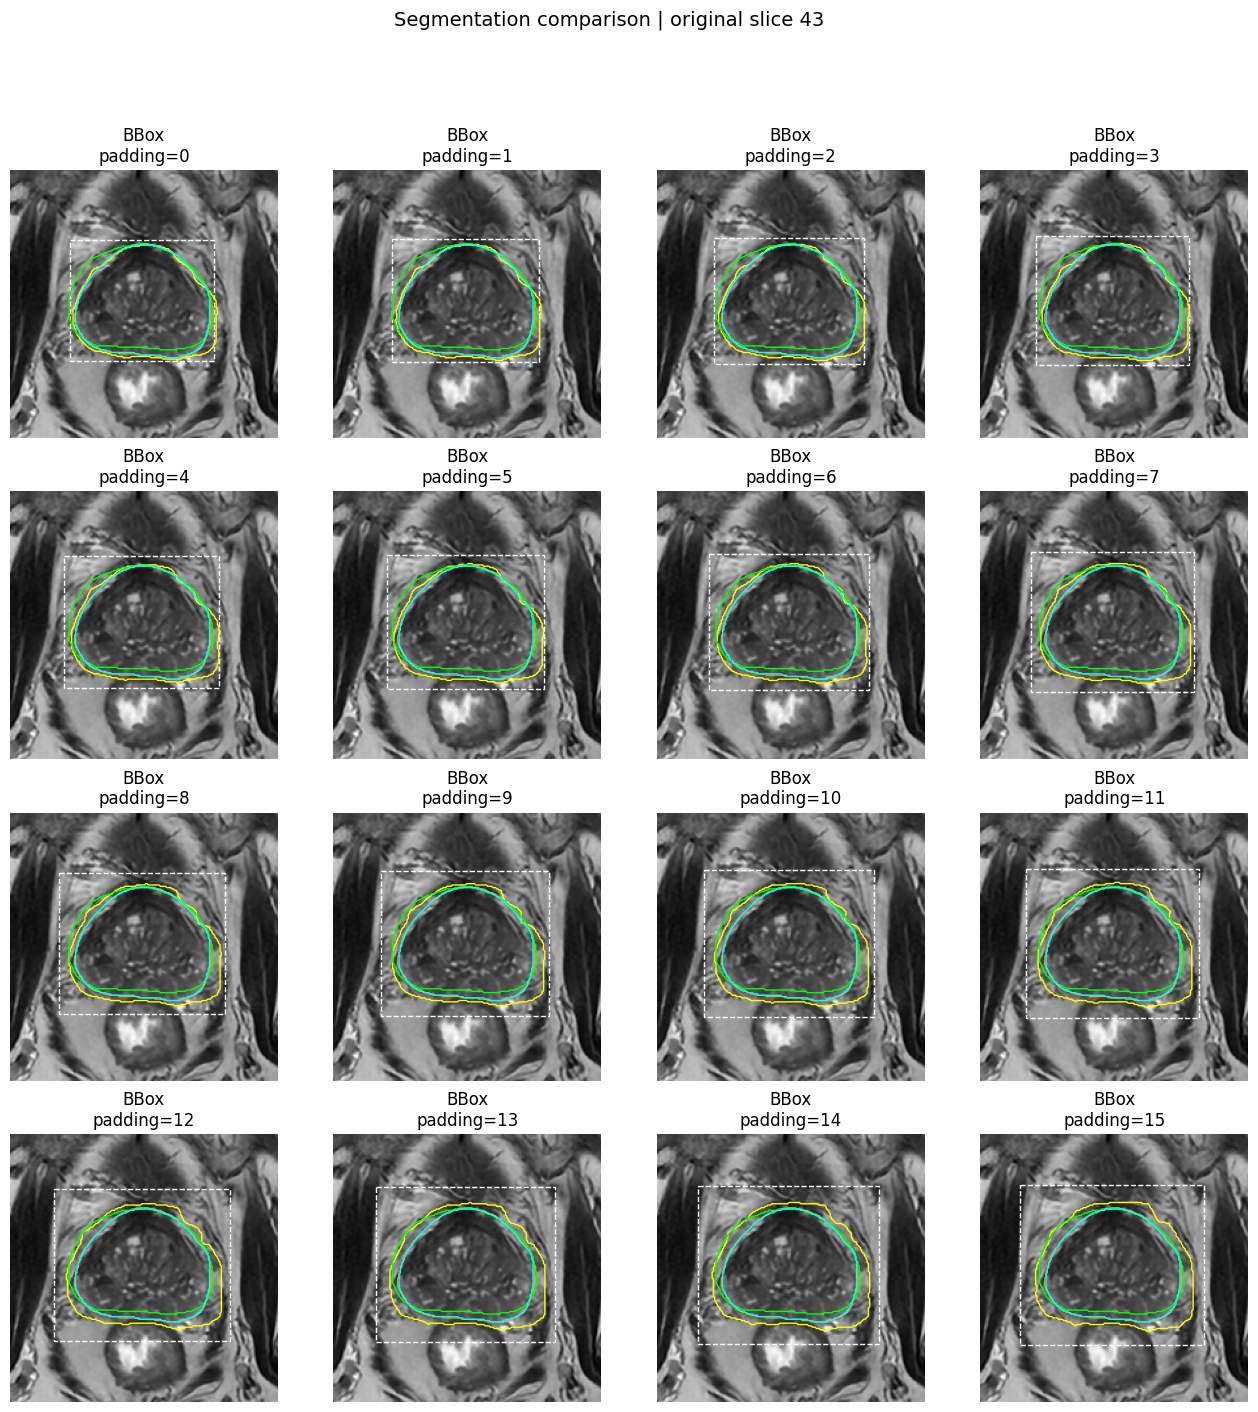

In [13]:
from pathlib import Path

output_folder = Path("For Midway Presentation")
output_path = output_folder / f"bbox_Sub_{sub_nr}_segmentation_comparison_slice_{selected_slice}+recontour+GT.png"

interactive_single_slice_prompt_strategy_comparison(
    data=data,
    seg_results=seg_results,
    prompt_strategies=prompt_strategies,
    selected_slice=selected_slice,
    show_gt=True,
    plot_recontour=True,
    recontour_index=3,  # 0=B, 1=C, 2=D, 3=E (assuming that order)
    savefig=True,
    savepath=output_path
)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import find_contours


def interactive_single_slice_logit_comparison(
    data,
    logit_results,
    selected_slice,
    seg_results=None,
    prompt_strategies=None,
    zoom_fraction=0.20,
    figsize_per_plot=4,
    alpha=0.55,
    cmap="magma",
    vmin=None,
    vmax=None,
    savefig=True,
    savepath=f"logit_comparison_slice_{selected_slice}.png",
):
    img = np.asarray(data.img)
    dense = np.asarray(data.mask).astype(bool)

    image_z = selected_slice
    logit_z = 0
    pred_z = 0
    prompt_z = selected_slice

    strategy_names = list(logit_results.keys())

    if vmin is None:
        vmin = min(
            np.nanpercentile(np.asarray(logit_results[name]), 1)
            for name in strategy_names
        )

    if vmax is None:
        vmax = max(
            np.nanpercentile(np.asarray(logit_results[name]), 99)
            for name in strategy_names
        )

    def draw_contour(ax, mask, color="lime", linewidth=1.0, linestyle="-"):
        if mask is None or not np.any(mask):
            return

        contours = find_contours(mask.astype(float), 0.5)

        for contour in contours:
            ax.plot(
                contour[:, 1],
                contour[:, 0],
                color=color,
                linewidth=linewidth,
                linestyle=linestyle,
            )

    def draw_prompts(ax, prompt_dict, z, x0, y0):
        if prompt_dict is None:
            return

        if z not in prompt_dict:
            return

        prompts = prompt_dict[z]

        points = prompts.get("points", None)
        labels = prompts.get("point_labels", None)

        if points is not None and labels is not None:
            points = np.asarray(points)
            labels = np.asarray(labels)

            pos = points[labels == 1]
            neg = points[labels == 0]

            if len(pos) > 0:
                ax.scatter(
                    pos[:, 0] - x0,
                    pos[:, 1] - y0,
                    marker="+",
                    s=25,
                    linewidths=1.5,
                    color="lime",
                )

            if len(neg) > 0:
                ax.scatter(
                    neg[:, 0] - x0,
                    neg[:, 1] - y0,
                    marker="x",
                    s=25,
                    linewidths=1.3,
                    color="red",
                )

        boxes = prompts.get("boxes", None)

        if boxes is None:
            boxes = prompts.get("bbox", None)

        if boxes is not None:
            boxes = np.asarray(boxes)

            if boxes.ndim == 1:
                boxes = boxes[None, :]

            for box in boxes:
                x_min, y_min, x_max, y_max = box

                rect = plt.Rectangle(
                    (x_min - x0, y_min - y0),
                    x_max - x_min,
                    y_max - y_min,
                    fill=False,
                    linestyle="--",
                    edgecolor="blue",
                    linewidth=1,
                )

                ax.add_patch(rect)

    def get_crop():
        base_mask = dense[image_z]

        if np.any(base_mask):
            ys, xs = np.where(base_mask)
            cy, cx = ys.mean(), xs.mean()
        else:
            cy, cx = np.array(img.shape[1:]) / 2

        H, W = img.shape[1:]
        crop_h = int(H * zoom_fraction)
        crop_w = int(W * zoom_fraction)

        y0 = max(0, int(cy - crop_h // 2))
        y1 = min(H, int(cy + crop_h // 2))
        x0 = max(0, int(cx - crop_w // 2))
        x1 = min(W, int(cx + crop_w // 2))

        return x0, x1, y0, y1

    x0, x1, y0, y1 = get_crop()

    n = len(strategy_names)
    ncols = 4
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot * ncols, figsize_per_plot * nrows),
        squeeze=False,
    )

    axes_flat = axes.flatten()
    im = None

    for ax, name in zip(axes_flat, strategy_names):
        logits = np.asarray(logit_results[name])

        ax.imshow(
            img[image_z, y0:y1, x0:x1],
            cmap="gray",
        )

        im = ax.imshow(
            logits[logit_z, y0:y1, x0:x1],
            cmap=cmap,
            alpha=alpha,
            vmin=vmin,
            vmax=vmax,
        )

        draw_contour(
            ax,
            dense[image_z, y0:y1, x0:x1],
            color="orange",
            linewidth=0.8,
        )

        if seg_results is not None and name in seg_results:
            pred = np.asarray(seg_results[name]).astype(bool)

            draw_contour(
                ax,
                pred[pred_z, y0:y1, x0:x1],
                color="lime",
                linewidth=1.0,
            )

        if prompt_strategies is not None and name in prompt_strategies:
            draw_prompts(
                ax=ax,
                prompt_dict=prompt_strategies[name],
                z=prompt_z,
                x0=x0,
                y0=y0,
            )

        ax.set_title(name)
        ax.axis("off")

    for ax in axes_flat[len(strategy_names):]:
        ax.axis("off")

    fig.subplots_adjust(
        right=0.90,
        wspace=0.05,
        hspace=0.20,
    )

    if im is not None:
        cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
        fig.colorbar(im, cax=cbar_ax, label="Logit")

    fig.suptitle(
        f"Logit comparison | original slice {selected_slice}",
        fontsize=14,
    )

    if savefig:
        fig.savefig(
            savepath,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

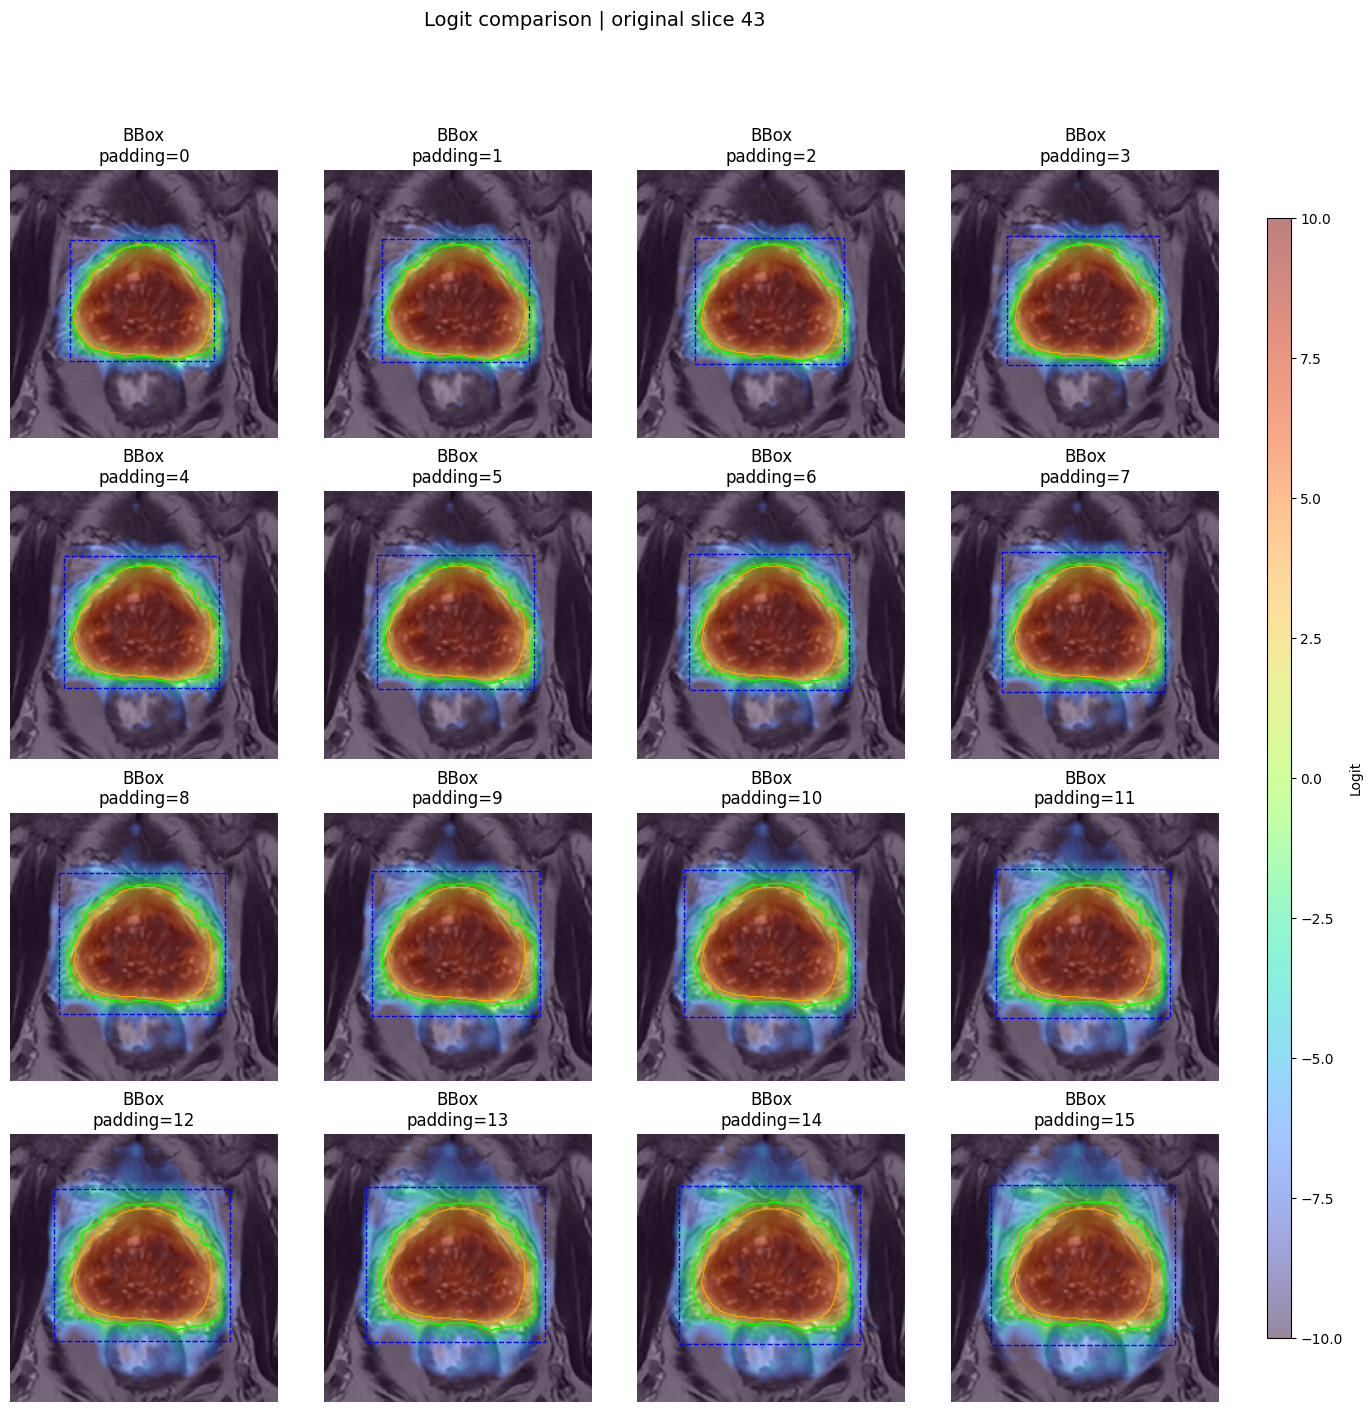

In [10]:
from pathlib import Path

output_folder = Path("For Midway Presentation")
output_path = output_folder / f"bbox_Sub_{sub_nr}_logit_comparison_slice_{selected_slice}.png"

interactive_single_slice_logit_comparison(
    data=data,
    logit_results=log_results,
    seg_results=seg_results,
    prompt_strategies=prompt_strategies,
    selected_slice=selected_slice,
    cmap="turbo",
    alpha=0.50,
    vmin=-10,
    vmax=10,    
    zoom_fraction=0.20,
    figsize_per_plot=4,
    savefig=True,
    savepath=output_path,
)

In [11]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import find_contours


def save_logit_comparison_pngs(
    data,
    logit_results,
    seg_results=None,
    output_folder="Logit_Comparison",
    zoom_fraction=0.35,
    figsize_per_plot=4,
    alpha=0.55,
    cmap="magma",
    vmin=-10,
    vmax=10,
    dpi=300,
):

    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    img = np.asarray(data.img)
    dense = np.asarray(data.mask).astype(bool)
    gt = np.asarray(data.gt).astype(bool)

    strategy_names = list(logit_results.keys())

    def draw_contour(ax, mask, color="lime", linewidth=1.1):
        if mask is None or not np.any(mask):
            return

        contours = find_contours(mask.astype(float), 0.5)

        for contour in contours:
            ax.plot(
                contour[:, 1],
                contour[:, 0],
                color=color,
                linewidth=linewidth,
            )

    def get_crop(z):

        if np.any(gt[z]):
            ys, xs = np.where(gt[z])
            cy, cx = ys.mean(), xs.mean()
        elif np.any(dense[z]):
            ys, xs = np.where(dense[z])
            cy, cx = ys.mean(), xs.mean()
        else:
            cy, cx = np.array(img.shape[1:]) / 2

        H, W = img.shape[1:]

        crop_h = int(H * zoom_fraction)
        crop_w = int(W * zoom_fraction)

        y0 = max(0, int(cy - crop_h // 2))
        y1 = min(H, int(cy + crop_h // 2))
        x0 = max(0, int(cx - crop_w // 2))
        x1 = min(W, int(cx + crop_w // 2))

        return x0, x1, y0, y1

    gt_slices = np.where(np.any(gt, axis=(1, 2)))[0]

    for z in gt_slices:

        x0, x1, y0, y1 = get_crop(z)

        n = len(strategy_names)
        ncols = 4
        nrows = int(np.ceil(n / ncols))

        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(figsize_per_plot * ncols,
                     figsize_per_plot * nrows),
            squeeze=False,
        )

        axes = axes.flatten()

        for ax, name in zip(axes, strategy_names):

            logits = np.asarray(logit_results[name])

            ax.imshow(
                img[z, y0:y1, x0:x1],
                cmap="gray",
            )

            im = ax.imshow(
                logits[z, y0:y1, x0:x1],
                cmap=cmap,
                alpha=alpha,
                vmin=vmin,
                vmax=vmax,
            )

            if seg_results is not None and name in seg_results:
                pred = np.asarray(seg_results[name]).astype(bool)
                draw_contour(
                    ax,
                    pred[z, y0:y1, x0:x1],
                    color="lime",
                    linewidth=1.1,
                )

            ax.set_title(name)
            ax.axis("off")

        for ax in axes[len(strategy_names):]:
            ax.axis("off")

        fig.subplots_adjust(
            right=0.90,
            wspace=0.05,
            hspace=0.20,
        )

        cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
        fig.colorbar(im, cax=cbar_ax, label="Logit")

        fig.suptitle(
            f"Logit comparison | GT slice {z}",
            fontsize=14,
        )

        save_path = output_folder / f"logit_comparison_slice_{z:03d}.png"

        fig.savefig(
            save_path,
            dpi=dpi,
            bbox_inches="tight",
        )

        plt.close(fig)

    print(f"Saved {len(gt_slices)} figures to: {output_folder}")